# Total mensual de viajeros internacionales

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv('../Datos/Datos.csv')

### Limpieza previa

In [5]:
# Columna de fecha real, para poder ordenar/agrupar correctamente en el tiempo
df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes cod'].astype(str) + '-01')

# Duplicados exactos
duplicados = df.duplicated().sum()
if duplicados > 0:
    print(f"Se eliminan {duplicados} filas duplicadas exactas")
    df = df.drop_duplicates()

# Filas sin valor de Viajero no se pueden sumar
nulos_viajero = df['Viajero'].isna().sum()
if nulos_viajero > 0:
    print(f"Se eliminan {nulos_viajero} filas sin valor de Viajero")
    df = df.dropna(subset=['Viajero'])

# Viajero debe ser numérico (por si viene como texto)
df['Viajero'] = pd.to_numeric(df['Viajero'], errors='coerce')
df = df.dropna(subset=['Viajero'])

print(f"Filas finales tras limpieza: {len(df)}")
print(f"Rango de fechas: {df['Fecha'].min().date()} a {df['Fecha'].max().date()}")

Filas finales tras limpieza: 161036
Rango de fechas: 2009-01-01 a 2026-06-01


### Train (70%) & Test (30%)

In [6]:
# En series de tiempo no se mezcla el orden: "prueba" debe ser el tramo
# más reciente, simulando un escenario real de pronóstico a futuro.
fechas_unicas = sorted(df['Fecha'].unique())
n_fechas = len(fechas_unicas)
corte = int(round(n_fechas * 0.7))
fecha_corte = fechas_unicas[corte]

print(f"\nTotal de meses en el dataset: {n_fechas}")
print(f"Entrenamiento: {corte} meses ({fechas_unicas[0].strftime('%Y-%m')} a {fechas_unicas[corte-1].strftime('%Y-%m')})")
print(f"Prueba: {n_fechas - corte} meses ({fecha_corte.strftime('%Y-%m')} a {fechas_unicas[-1].strftime('%Y-%m')})")

df_train = df[df['Fecha'] < fecha_corte].copy()
df_test = df[df['Fecha'] >= fecha_corte].copy()

print(f"\nFilas entrenamiento: {len(df_train)} ({len(df_train)/len(df)*100:.1f}%)")
print(f"Filas prueba:        {len(df_test)} ({len(df_test)/len(df)*100:.1f}%)")


Total de meses en el dataset: 210
Entrenamiento: 147 meses (2009-01 a 2021-03)
Prueba: 63 meses (2021-04 a 2026-06)

Filas entrenamiento: 131442 (81.6%)
Filas prueba:        29594 (18.4%)


### Series de tiempo mensuales


Serie total mensual (entrenamiento) - primeras filas:
Fecha
2009-01-01    183505.590535
2009-02-01    149426.253908
2009-03-01    174237.227095
2009-04-01    182842.489917
2009-05-01    133194.667651
Freq: MS, Name: Viajero, dtype: float64

Estadísticas descriptivas de la serie:
count       147.000000
mean     237120.911443
std      101886.471008
min        9779.000000
25%      176751.538642
50%      216160.621785
75%      306145.757849
max      515820.445952
Name: Viajero, dtype: float64


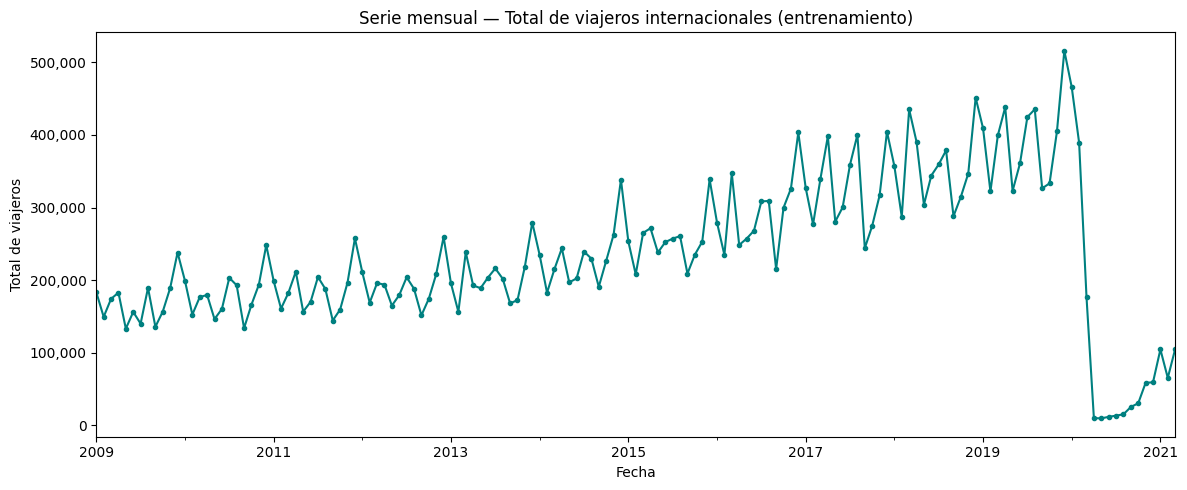

In [7]:
# --- a. Serie obligatoria: Total mensual de viajeros internacionales ---
serie_total_mensual = (
    df_train.groupby('Fecha')['Viajero']
    .sum()
    .asfreq('MS')  # fuerza frecuencia mensual continua (rellena huecos con NaN si falta un mes)
)

huecos = serie_total_mensual.isna().sum()
if huecos > 0:
    print(f"\nSe encontraron {huecos} meses sin datos dentro del rango de entrenamiento (huecos de calendario)")
    serie_total_mensual = serie_total_mensual.fillna(0)

print("\nSerie total mensual (entrenamiento) - primeras filas:")
print(serie_total_mensual.head())
print("\nEstadísticas descriptivas de la serie:")
print(serie_total_mensual.describe())

fig, ax = plt.subplots(figsize=(12, 5))
serie_total_mensual.plot(ax=ax, color='teal', marker='o', markersize=3)
ax.set_title('Serie mensual — Total de viajeros internacionales (entrenamiento)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Total de viajeros')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

### Recoemndación: hacerlo con conjunto PRUEBA

In [8]:
serie_total_mensual_test = (
    df_test.groupby('Fecha')['Viajero']
    .sum()
    .asfreq('MS')
    .fillna(0)
)

# Guardar series
serie_total_mensual.to_csv('../Datos/serie_total_mensual_train.csv', header=['Viajero'])
serie_total_mensual_test.to_csv('../Datos/serie_total_mensual_test.csv', header=['Viajero'])
print("\nArchivos guardados: serie_total_mensual_train.csv, serie_total_mensual_test.csv")


Archivos guardados: serie_total_mensual_train.csv, serie_total_mensual_test.csv
